In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import warnings 
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("taxi_trip_pricing.csv")
df.head(5)

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180


In [3]:
df.shape

(1000, 11)

In [4]:
df.isnull().sum()

Trip_Distance_km         50
Time_of_Day              50
Day_of_Week              50
Passenger_Count          50
Traffic_Conditions       50
Weather                  50
Base_Fare                50
Per_Km_Rate              50
Per_Minute_Rate          50
Trip_Duration_Minutes    50
Trip_Price               49
dtype: int64

In [5]:
df.columns

Index(['Trip_Distance_km', 'Time_of_Day', 'Day_of_Week', 'Passenger_Count',
       'Traffic_Conditions', 'Weather', 'Base_Fare', 'Per_Km_Rate',
       'Per_Minute_Rate', 'Trip_Duration_Minutes', 'Trip_Price'],
      dtype='object')

In [6]:
df.dtypes

Trip_Distance_km         float64
Time_of_Day               object
Day_of_Week               object
Passenger_Count          float64
Traffic_Conditions        object
Weather                   object
Base_Fare                float64
Per_Km_Rate              float64
Per_Minute_Rate          float64
Trip_Duration_Minutes    float64
Trip_Price               float64
dtype: object

In [7]:
df.describe()

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,951.000000
mean,27.070547,2.476842,3.502989,1.233316,0.292916,62.118116,56.874773
std,19.905300,1.102249,0.870162,0.429816,0.115592,32.154406,40.469791
min,1.230000,1.000000,2.010000,0.500000,0.100000,5.010000,6.126900
25%,12.632500,1.250000,2.730000,0.860000,0.190000,35.882500,33.742650
50%,25.830000,2.000000,3.520000,1.220000,0.290000,61.860000,50.074500
75%,38.405000,3.000000,4.260000,1.610000,0.390000,89.055000,69.099350
max,146.067047,4.000000,5.000000,2.000000,0.500000,119.840000,332.043689


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    object 
 2   Day_of_Week            950 non-null    object 
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    object 
 5   Weather                950 non-null    object 
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


In [9]:
num_cols=df.select_dtypes(include=["int64","float64"]).columns
cat_cols=df.select_dtypes(include=["object"]).columns
print("Numerical Columns")
print(num_cols)
print("=========================================================================================")
print("Categorical Columns")
print(cat_cols)

Numerical Columns
Index(['Trip_Distance_km', 'Passenger_Count', 'Base_Fare', 'Per_Km_Rate',
       'Per_Minute_Rate', 'Trip_Duration_Minutes', 'Trip_Price'],
      dtype='object')
Categorical Columns
Index(['Time_of_Day', 'Day_of_Week', 'Traffic_Conditions', 'Weather'], dtype='object')


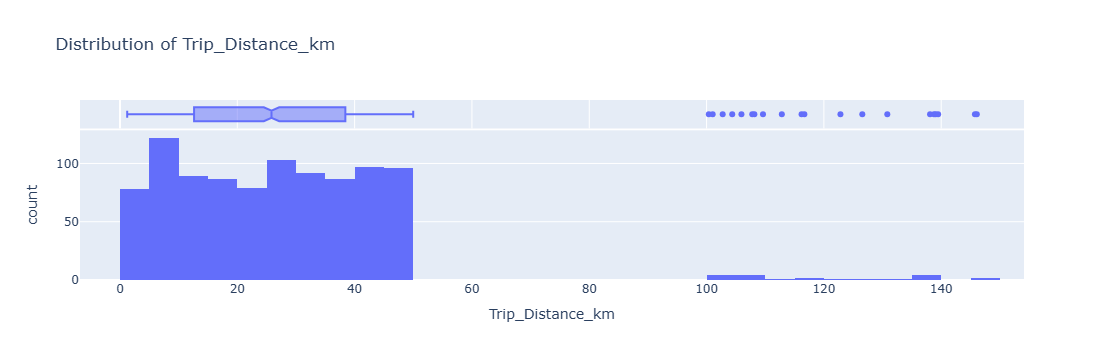

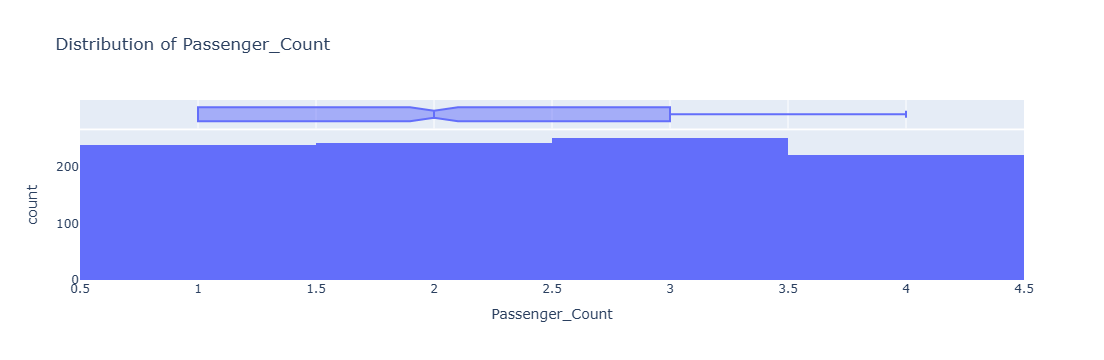

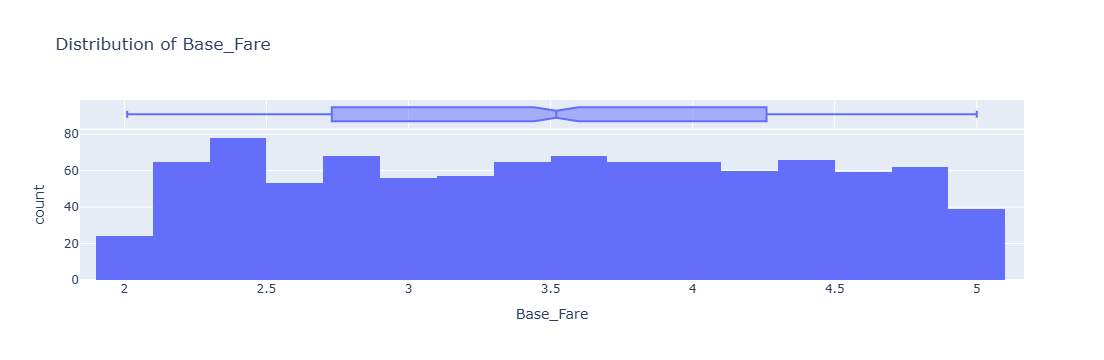

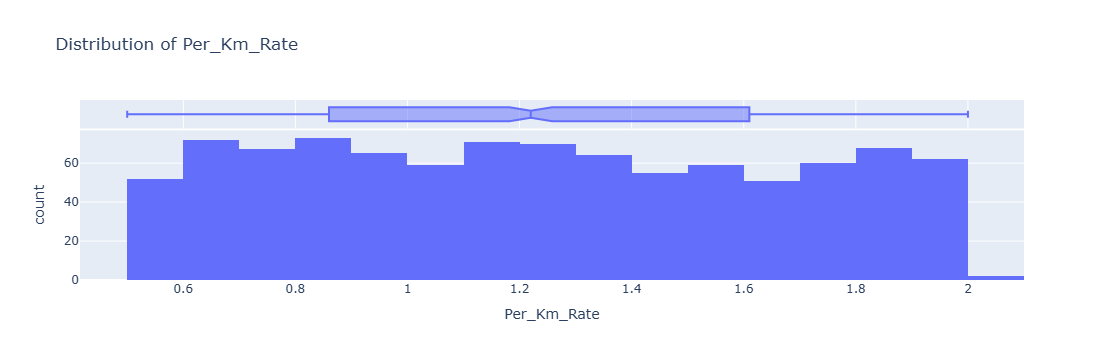

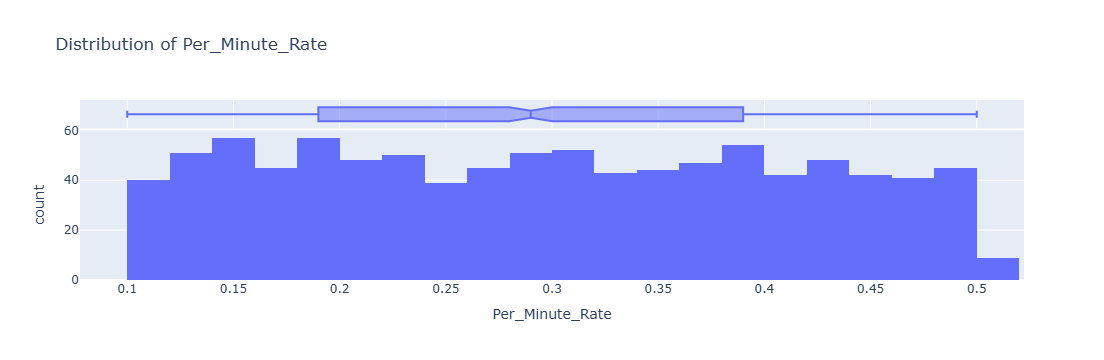

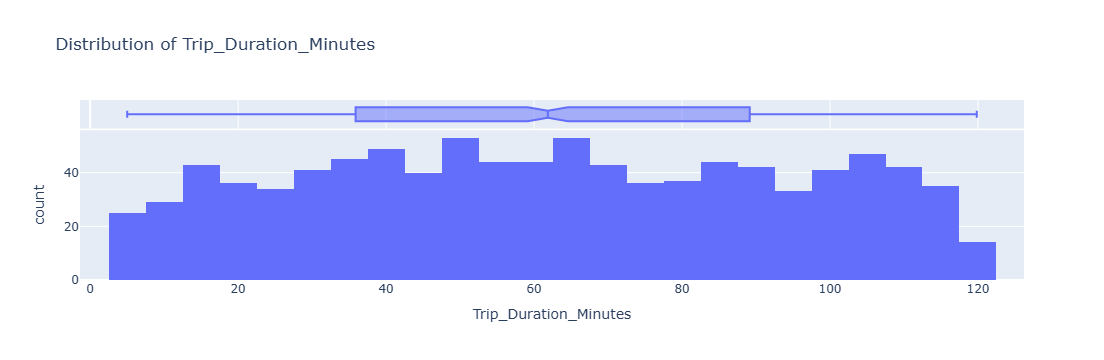

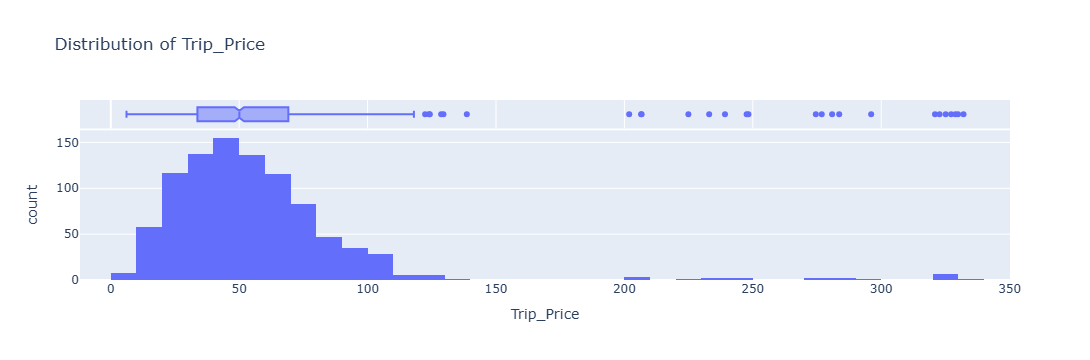

In [10]:
for col in num_cols:
    fig=px.histogram(df,x=col,marginal="box",title=f"Distribution of {col}")
    fig.show()

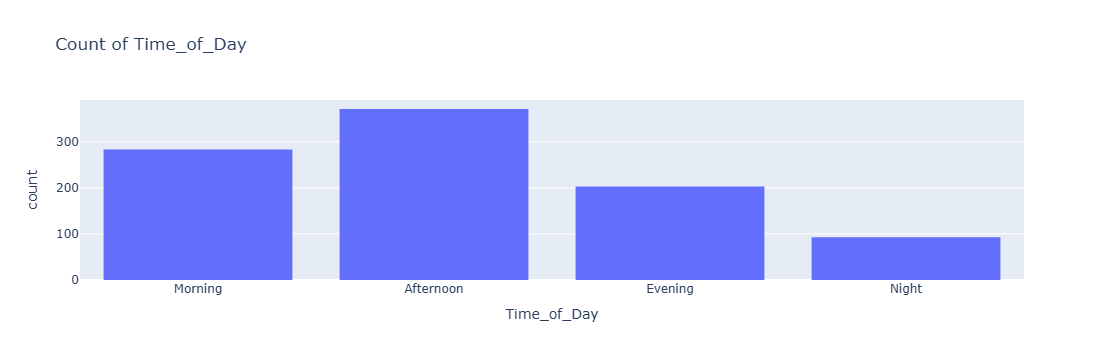

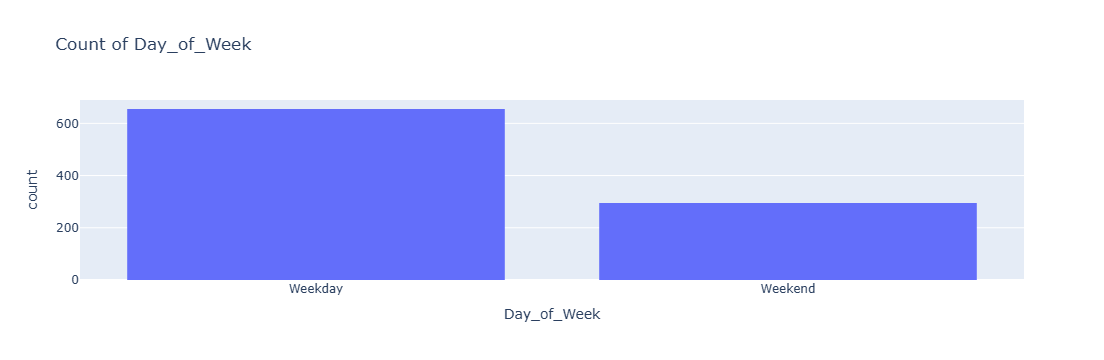

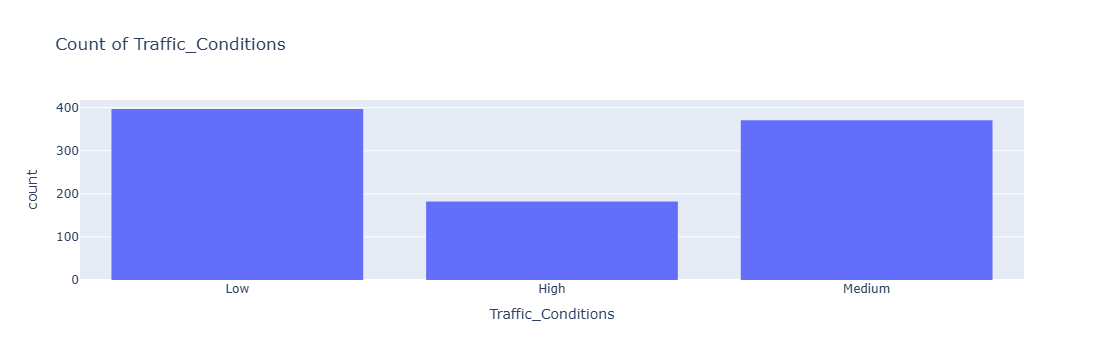

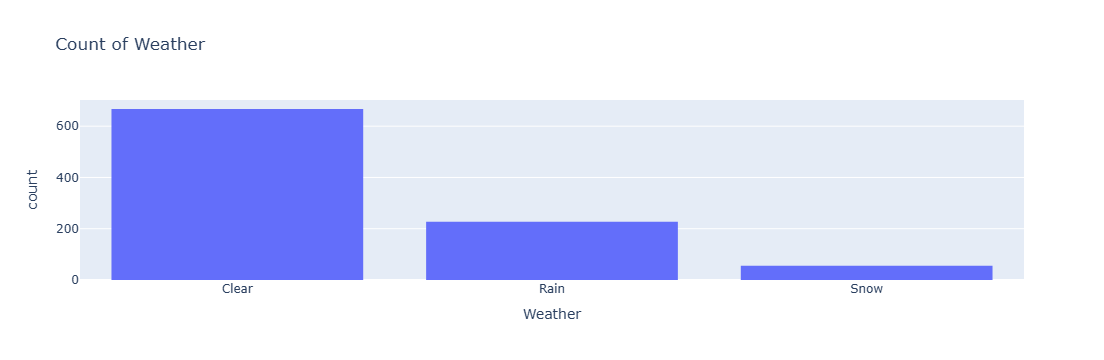

In [11]:
for col in cat_cols:
    fig=px.histogram(df,x=col,title=f"Count of {col}")
    fig.show()

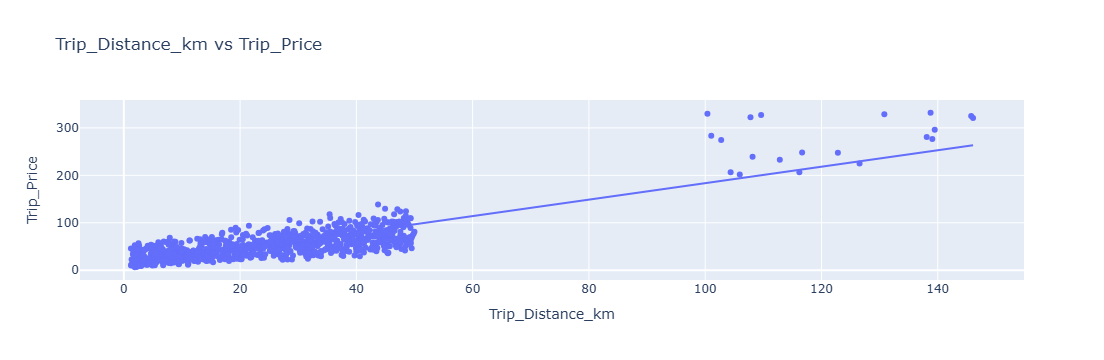

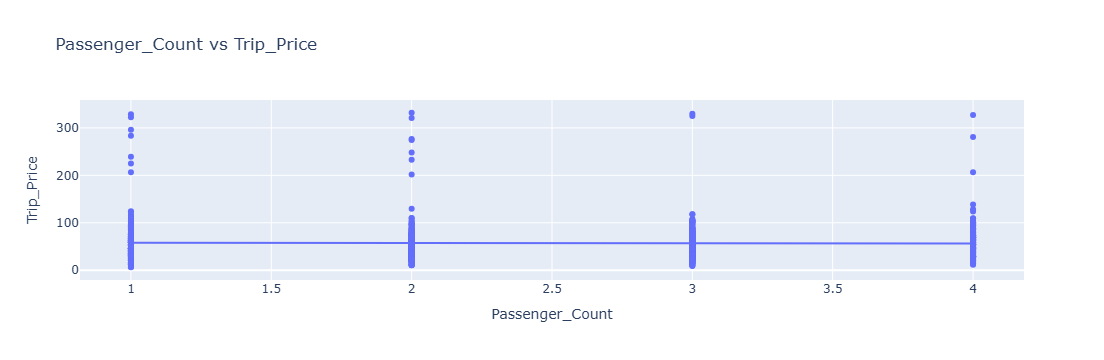

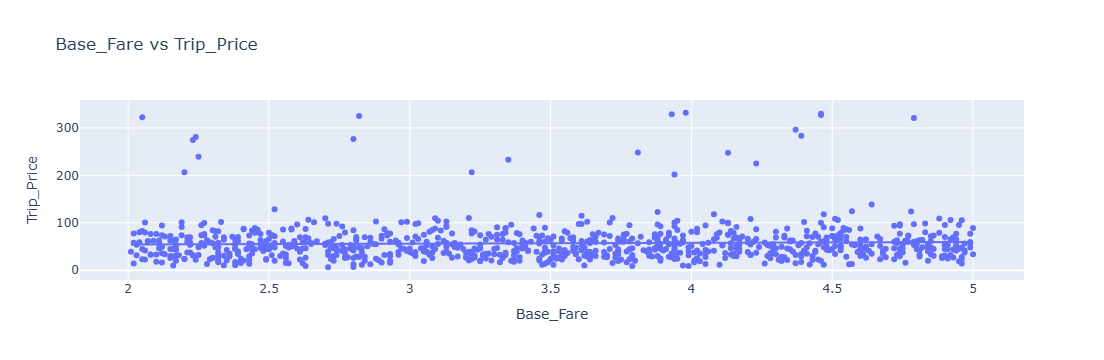

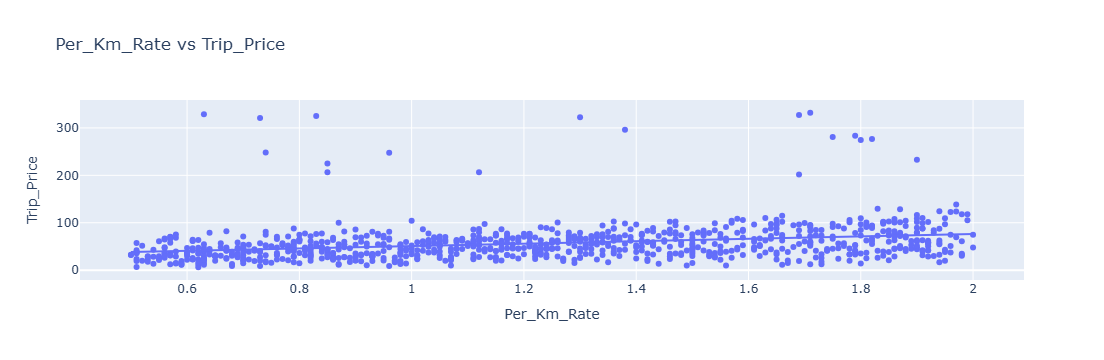

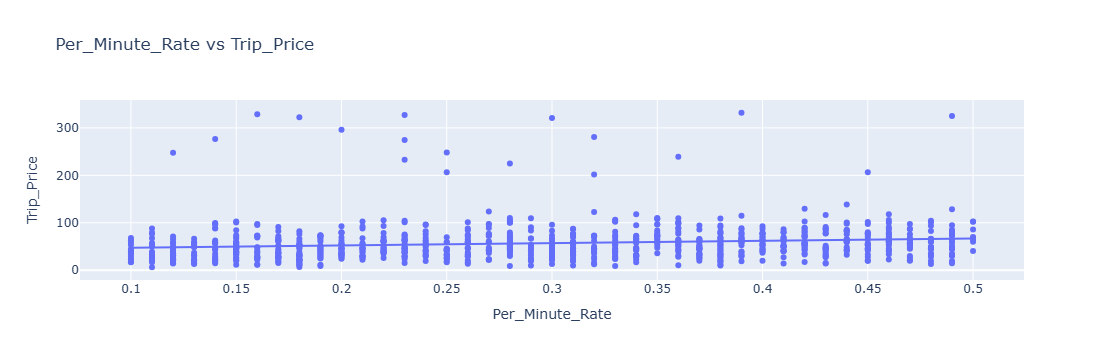

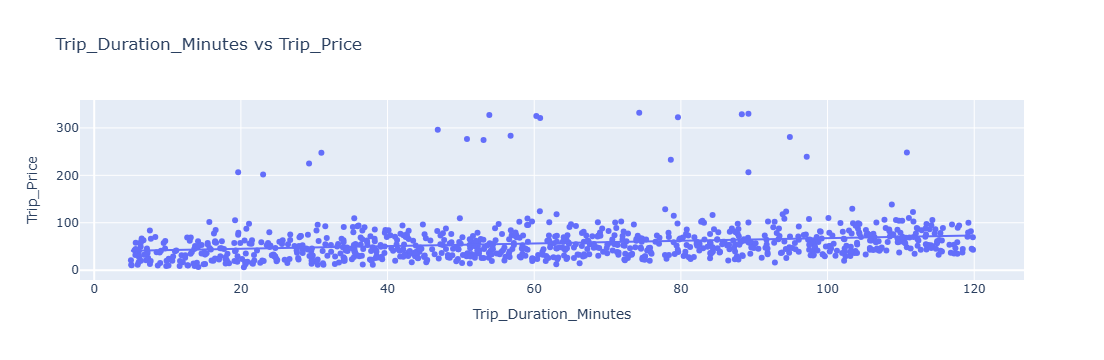

DuplicateError: Expected unique column names, got:
- 'Trip_Price' 2 times

In [12]:
for col in num_cols:
    fig = px.scatter(
        df, x=col, y='Trip_Price',
        trendline="ols",
        title=f"{col} vs Trip_Price"
    )
    fig.show()

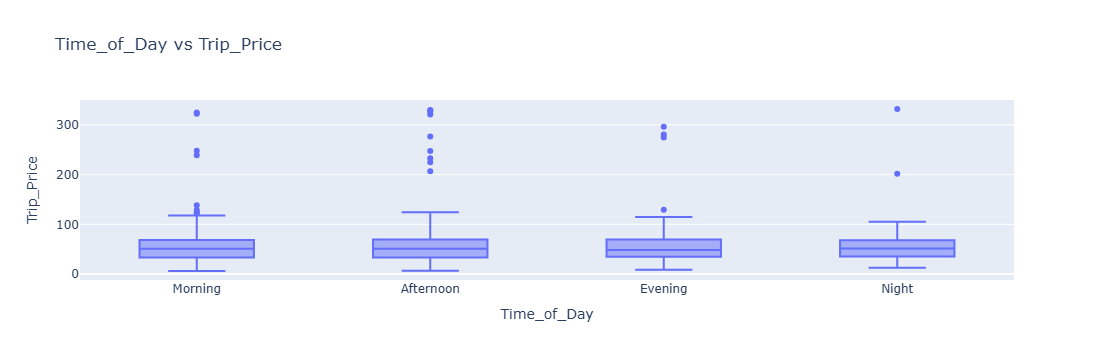

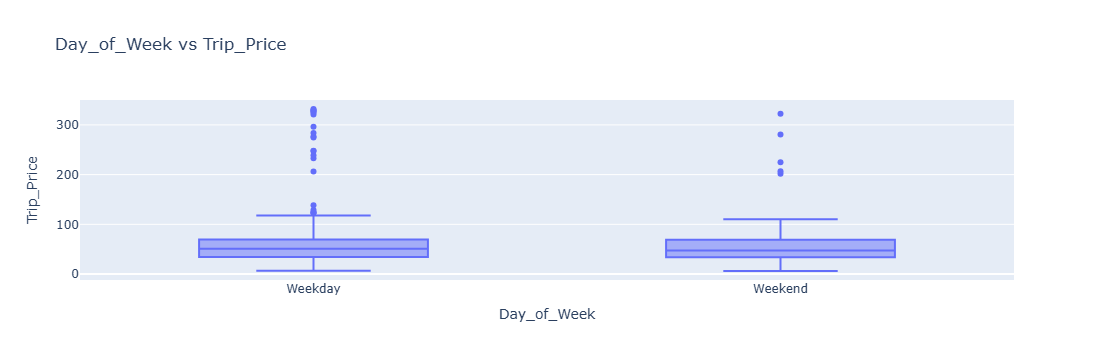

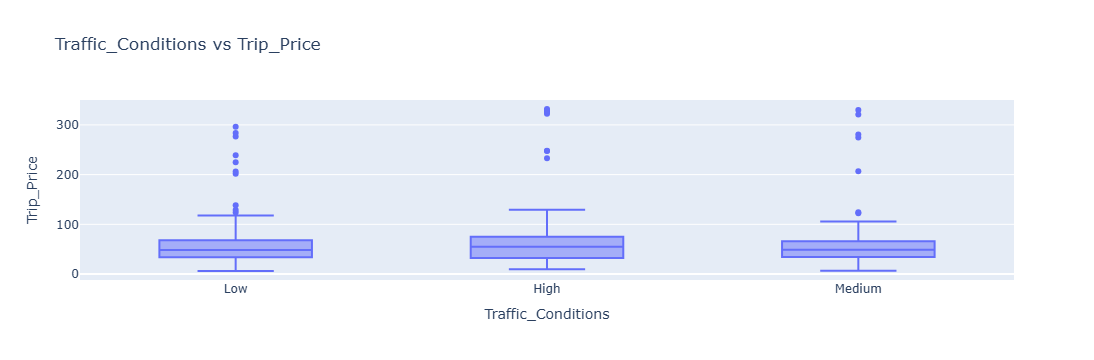

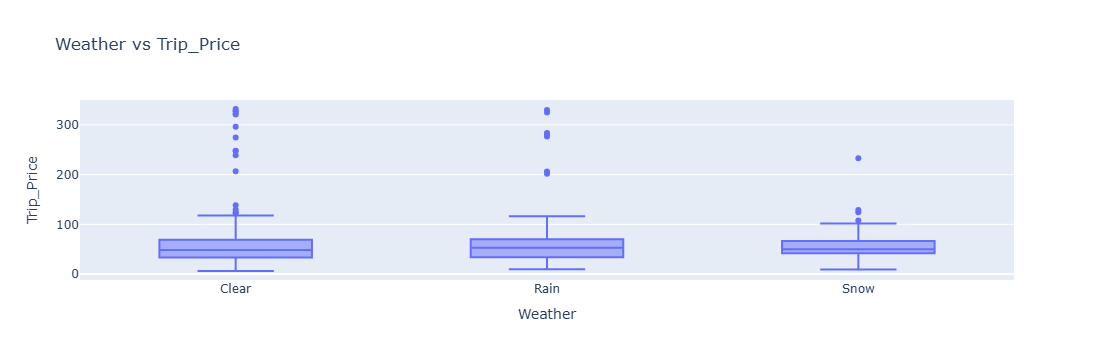

In [13]:
for col in cat_cols:
    fig = px.box(
        df, x=col, y='Trip_Price',
        title=f"{col} vs Trip_Price"
    )
    fig.show()

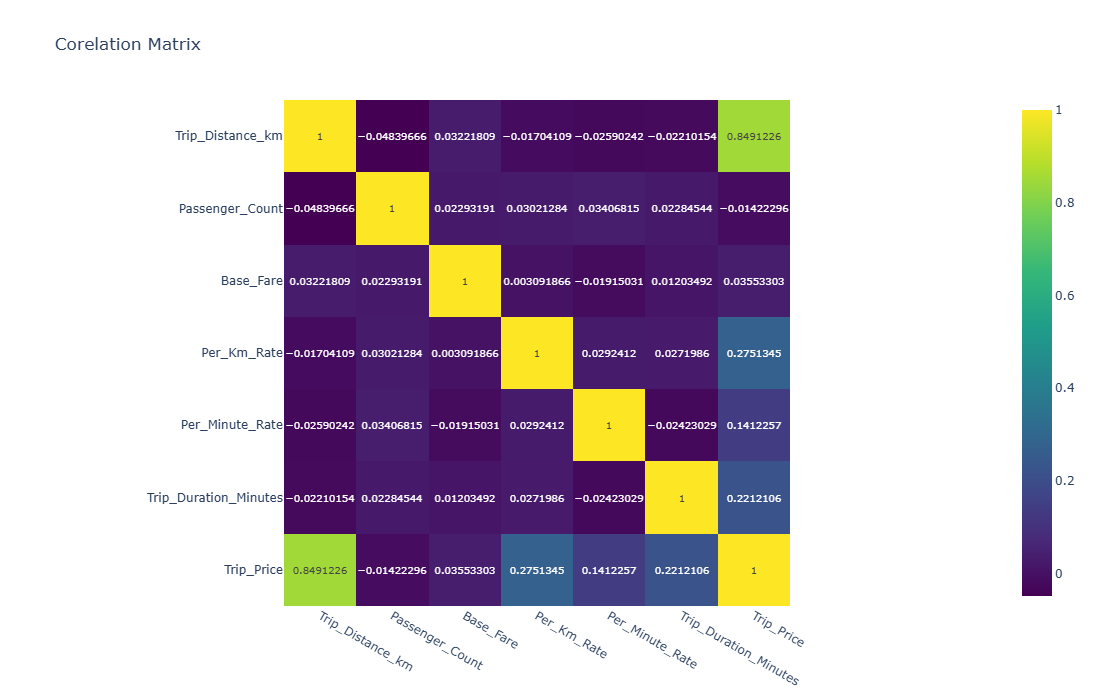

In [14]:
import plotly.figure_factory as ff
num_df=df.select_dtypes(include=["float64","int64"])
corr = num_df.corr()
fig=px.imshow(
    corr,
    text_auto=True,
    color_continuous_scale="Viridis",
    title="Corelation Matrix")
fig.update_layout(height =700,
                 width=1000)
fig.show()

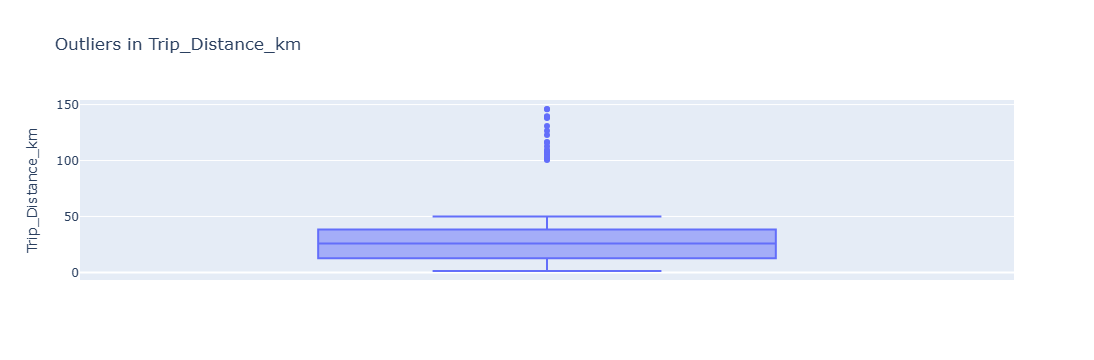

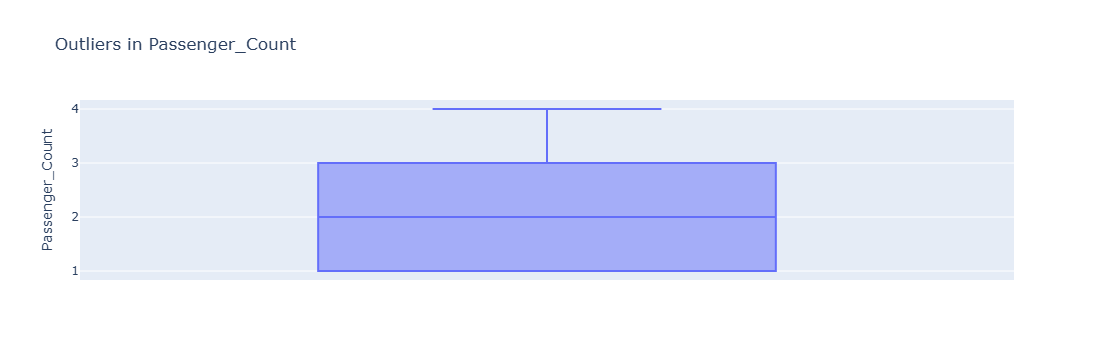

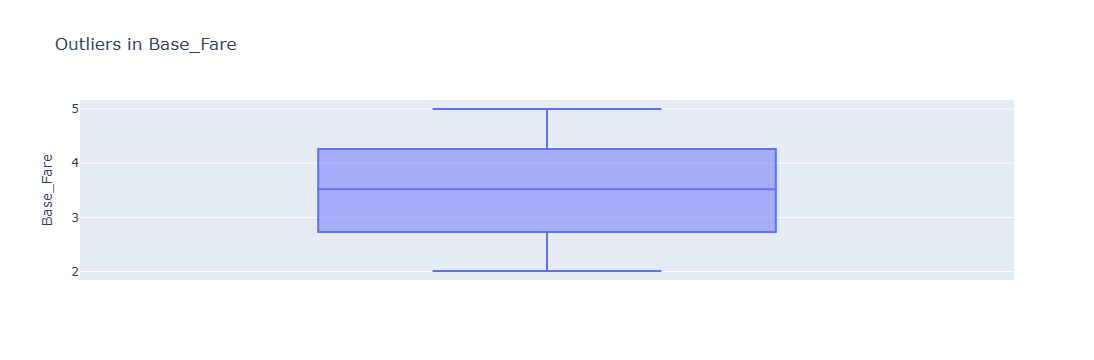

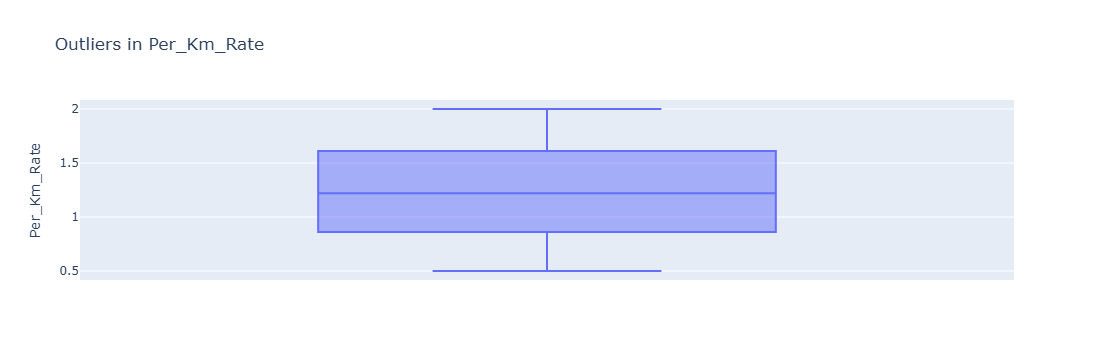

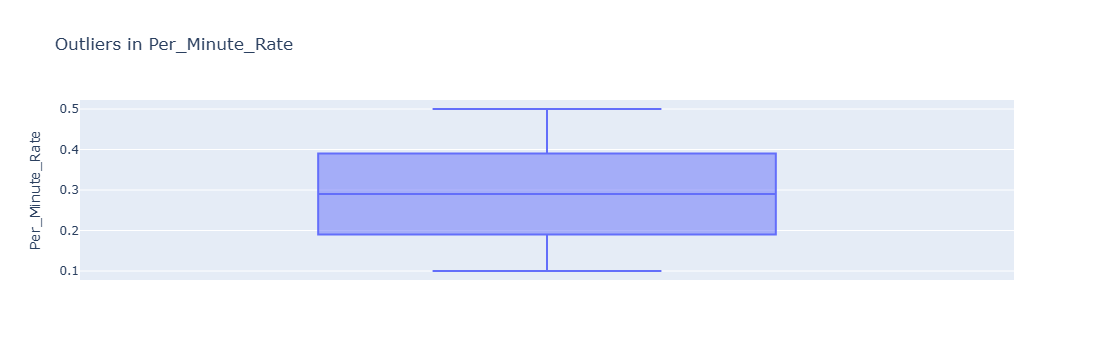

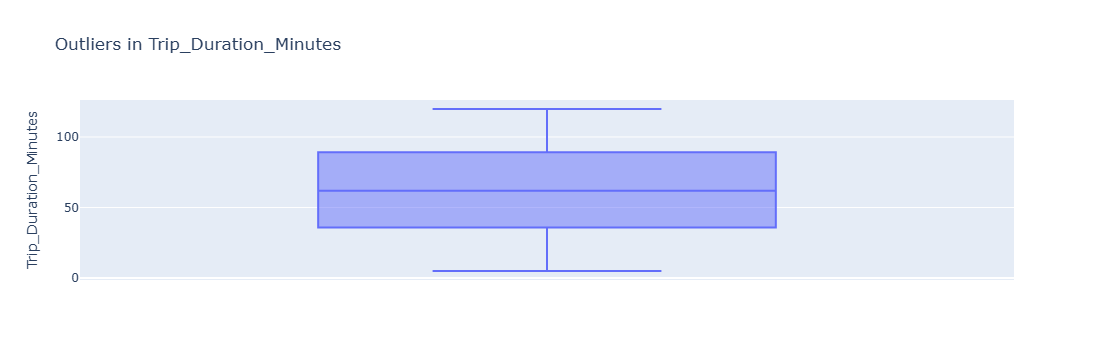

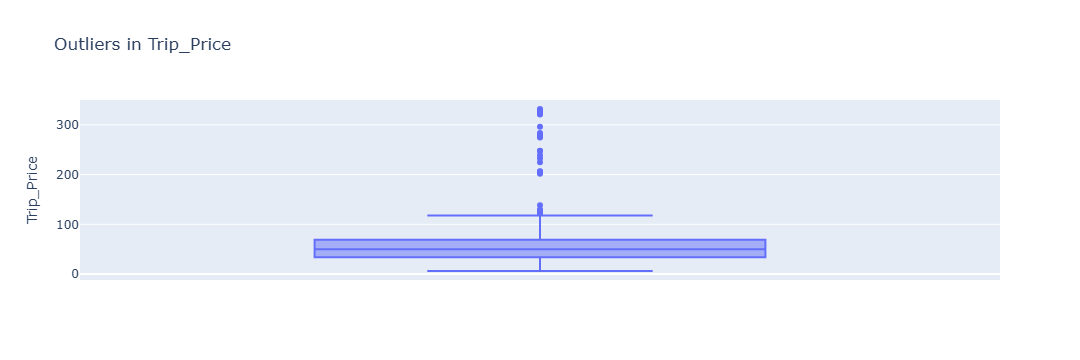

In [15]:
## Outliers
for col in num_cols:
    fig=px.box(df,y=col,title=f"Outliers in {col}")
    fig.show()

In [16]:
## task-2->EDA
df=df.dropna(subset=["Trip_Price"])
## Num cols
for col in num_cols:
    df[col]=df[col].fillna(df[col].median())
## Cat cols
for col in cat_cols:
    df[col]=df[col].fillna(df[col].mode())

In [17]:
df=pd.get_dummies(df,columns=cat_cols,drop_first=True)
df.head(5)

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Day_of_Week_Weekend,Traffic_Conditions_Low,Traffic_Conditions_Medium,Weather_Rain,Weather_Snow
0,19.35,3.0,3.56,0.80,0.32,53.82,36.2624,False,True,False,False,True,False,False,False
2,36.87,1.0,2.70,1.21,0.15,37.27,52.9032,True,False,False,True,False,False,False,False
3,30.33,4.0,3.48,0.51,0.15,116.81,36.4698,True,False,False,False,True,False,False,False
4,25.87,3.0,2.93,0.63,0.32,22.64,15.6180,True,False,False,False,False,False,False,False
5,8.64,2.0,2.55,1.71,0.48,89.33,60.2028,False,False,False,True,False,True,False,False


In [18]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X=df.drop("Trip_Price",axis=1)
y=df["Trip_Price"]
X_scaled=scaler.fit_transform(X)

In [19]:
## Task 3 Feature Engineering
df.columns

Index(['Trip_Distance_km', 'Passenger_Count', 'Base_Fare', 'Per_Km_Rate',
       'Per_Minute_Rate', 'Trip_Duration_Minutes', 'Trip_Price',
       'Time_of_Day_Evening', 'Time_of_Day_Morning', 'Time_of_Day_Night',
       'Day_of_Week_Weekend', 'Traffic_Conditions_Low',
       'Traffic_Conditions_Medium', 'Weather_Rain', 'Weather_Snow'],
      dtype='object')

In [ ]:
df["Estimated_Total"]=df["Base_Fare"]+df["Distance_Cost"]+df["Time_Cost"]

In [ ]:
df["Speed_kmph"]=df["Trip_Distance_km"]/(df["Trip_Duration_Minutes"]/60)

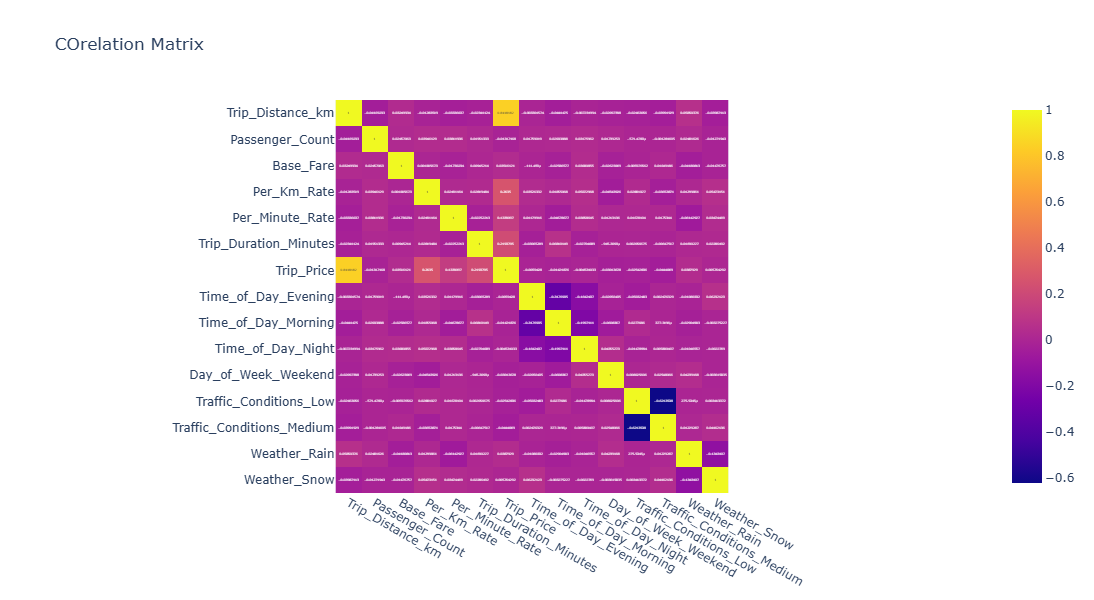

In [20]:
corr=df.corr(numeric_only=True)
fig=px.imshow(
    corr,
    text_auto=True,
    title="COrelation Matrix")
fig.update_layout(
    width=1000,
    height=600)
fig.show()

In [21]:
corr_target=corr["Trip_Price"].sort_values(ascending=False)
print(corr_target)

Trip_Price                   1.000000
Trip_Distance_km             0.841818
Per_Km_Rate                  0.263500
Trip_Duration_Minutes        0.219380
Per_Minute_Rate              0.133910
Weather_Rain                 0.038793
Base_Fare                    0.035161
Weather_Snow                 0.005764
Time_of_Day_Night           -0.004531
Time_of_Day_Evening         -0.005943
Passenger_Count             -0.013172
Time_of_Day_Morning         -0.014219
Traffic_Conditions_Low      -0.025428
Day_of_Week_Weekend         -0.030137
Traffic_Conditions_Medium   -0.044407
Name: Trip_Price, dtype: float64


In [22]:
df = df.drop(columns=[
    'Distance_Cost',
    'Time_Cost',
    'Base_Fare'
])

KeyError: "['Distance_Cost', 'Time_Cost'] not found in axis"

In [23]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.2,random_state=42)

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [25]:
lr=LinearRegression()
lr.fit(X_train,y_train)
y_pred=lr.predict(X_test)
mae_lr=mean_absolute_error(y_test,y_pred)
mse_lr=mean_squared_error(y_test,y_pred)
r2_lr=r2_score(y_test,y_pred)
print(mae_lr)
print(mse_lr)
print(r2_lr)

9.929563352323505
289.0258398343864
0.8763461733146286


In [26]:
dt=DecisionTreeRegressor(random_state=42)
dt.fit(X_train,y_train)
y_pred_dt=dt.predict(X_test)
mae_dt=mean_absolute_error(y_test,y_pred_dt)
mse_dt=mean_squared_error(y_test,y_pred_dt)
r2_dt=r2_score(y_test,y_pred_dt)
print(mae_dt)
print(mse_dt)
print(r2_dt)

10.550978544387235
392.86643548889145
0.8319200866182783


In [27]:
rf=RandomForestRegressor(random_state=42)
rf.fit(X_train,y_train)
y_pred_rf=rf.predict(X_test)
mae_rf=mean_absolute_error(y_test,y_pred_rf)
mse_rf=mean_squared_error(y_test,y_pred_rf)
r2_rf=r2_score(y_test,y_pred_rf)
print(mae_rf)
print(mse_rf)
print(r2_rf)

6.248285051845564
132.79633219390456
0.9431857903951866


In [28]:
gb=GradientBoostingRegressor(random_state=42)
gb.fit(X_train,y_train)
y_pred_gb=gb.predict(X_test)
mae_gb=mean_absolute_error(y_test,y_pred_gb)
mse_gb=mean_squared_error(y_test,y_pred_gb)
r2_gb=r2_score(y_test,y_pred_gb)
print(mae_gb)
print(mse_gb)
print(r2_gb)

5.260119861155902
132.0507251159437
0.9435047832175805


In [29]:
result_df=pd.DataFrame({
    "Model":["Linear_Regression","Decision_Tree","random_Forest","GradientBoosting"],
    "MAE":[mae_lr,mae_dt,mae_rf,mae_gb],
    "MSE":[mse_lr,mse_dt,mse_rf,mse_gb],
    "R2 Score":[r2_lr,r2_dt,r2_rf,r2_gb]})
result_df

,Model,MAE,MSE,R2 Score
0,Linear_Regression,9.929563,289.025840,0.876346
1,Decision_Tree,10.550979,392.866435,0.831920
2,random_Forest,6.248285,132.796332,0.943186
3,GradientBoosting,5.260120,132.050725,0.943505


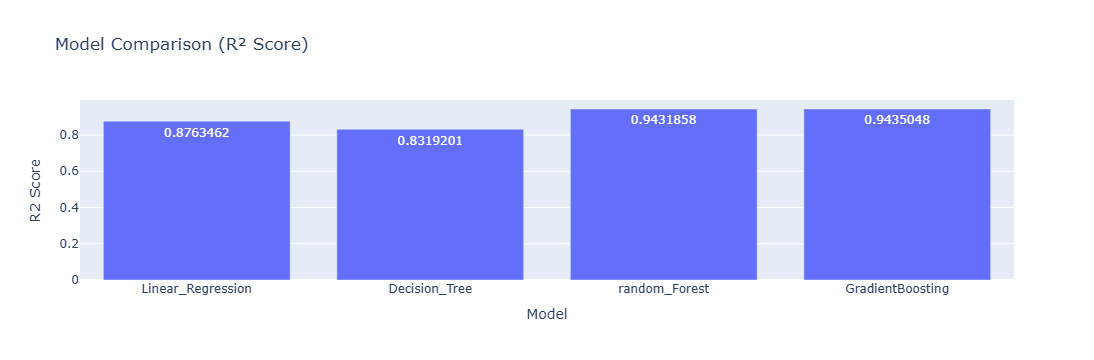

In [30]:
import plotly.express as px
fig = px.bar(
    result_df,
    x="Model",
    y="R2 Score",
    text_auto=True,
    title="Model Comparison (R² Score)"
)
fig.show()

In [31]:
from sklearn.model_selection import GridSearchCV
param_grid={
    "n_estimators":[100,200],
    "learning_rate":[0.05,0.1,0.2],
    "max_depth":[3,5],
    "subsample":[0.8,1.0]
}
gb=GradientBoostingRegressor(random_state=42)
grid=GridSearchCV(
    gb,
    param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1)
grid.fit(X_train, y_train)
print("Best Params:", grid.best_params_)
best_model = grid.best_estimator_
    

Best Params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}


In [32]:
y_pred_best=best_model.predict(X_test)
print("mAE:",mean_absolute_error(y_test,y_pred_best))
print("MSE",mean_squared_error(y_test,y_pred_best))
print("R2",r2_score(y_test,y_pred_best))

mAE: 5.287150293716743
MSE 129.1444961240901
R2 0.9447481541780198


In [33]:
feature_names = X.columns 
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
0,Trip_Distance_km,0.768377
3,Per_Km_Rate,0.096779
5,Trip_Duration_Minutes,0.076451
4,Per_Minute_Rate,0.047293
2,Base_Fare,0.005185
1,Passenger_Count,0.001645
13,Weather_Snow,0.001224
6,Time_of_Day_Evening,0.000923
10,Traffic_Conditions_Low,0.000605
7,Time_of_Day_Morning,0.000430


In [34]:
df = df.drop(columns=[
    'Passenger_Count',
    'Weather_Snow',
    'Weather_Rain',
    'Time_of_Day_Evening',
    'Time_of_Day_Morning',
    'Time_of_Day_Night',
    'Traffic_Conditions_Low',
    'Traffic_Conditions_Medium',
    'Day_of_Week_Weekend'
])

In [35]:
X = df.drop('Trip_Price', axis=1)
y = df['Trip_Price']

In [36]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [37]:
from sklearn.ensemble import GradientBoostingRegressor
model = GradientBoostingRegressor(random_state=42)
model.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [38]:
y_pred = model.predict(X_test)

In [39]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 5.343360155243171
RMSE: 11.606108101143091
R2: 0.9423705981735928
